In [ ]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')


from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function, plot_full_connectivity_tree_style
from test_schwefel.schwefel_function_jax import Schwefel2D, schwefel_loss 

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
critical_points_file = "./critical_points_schwefel_jax.csv"

outdir = './results/'

dataframe = pd.read_csv(critical_points_file, index_col=0)
no_maxima = dataframe["type"]!="maximum"
dataframe = dataframe[no_maxima]

saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
# minima_df = dataframe[dataframe["type"] != "maximum"]

build_schwefel = lambda p: Schwefel2D(*p)

display(dataframe)

,x1,x2,f_value,type,cp_index
0,0.341810,0.824375,2.171397e-01,minimum,0
1,0.824375,0.341809,2.171397e-01,minimum,0
2,0.824375,0.824375,2.550000e-08,minimum,0
3,0.034551,0.341810,5.724876e-01,minimum,0
4,0.341809,0.034551,5.724876e-01,minimum,0
5,0.824375,0.034551,3.553479e-01,minimum,0
6,0.034551,0.824375,3.553479e-01,minimum,0
7,0.034551,0.034551,7.106958e-01,minimum,0
8,0.341809,0.341809,4.342794e-01,minimum,0
13,0.561166,0.824375,7.195275e-01,saddle,1


In [3]:
all_results, minima, dataframe, paths = trace_connectivity(saddles_df,
                                                           minima_df,
                                                           dataframe,
                                                           schwefel_loss,
                                                           build_schwefel,
                                                           [],
                                                           optimizer='gd',
                                                           log_paths=True)



Tracing saddle:  13
Offset 0: [0.56136139 0.82437484]
converged:  True
Offset 1: [0.56097145 0.82437484]
converged:  True

Tracing saddle:  14
Offset 0: [0.82437485 0.16647881]
converged:  True
Offset 1: [0.82437485 0.16609588]
converged:  True

Tracing saddle:  15
Offset 0: [0.34180959 0.56136137]
converged:  True
Offset 1: [0.34180959 0.56097144]
converged:  True

Tracing saddle:  16
Offset 0: [0.56136153 0.34180962]
converged:  True
Offset 1: [0.56097159 0.34180962]
converged:  True

Tracing saddle:  17
Offset 0: [0.82437512 0.56136161]
converged:  True
Offset 1: [0.82437512 0.56097168]
converged:  True

Tracing saddle:  18
Offset 0: [0.16647905 0.34180958]
converged:  True
Offset 1: [0.16609611 0.34180958]
converged:  True

Tracing saddle:  19
Offset 0: [0.16647889 0.82437481]
converged:  True
Offset 1: [0.16609596 0.82437481]
converged:  True

Tracing saddle:  20
Offset 0: [0.34180957 0.1664788 ]
converged:  True
Offset 1: [0.34180957 0.16609586]
converged:  True

Tracing saddle:

In [4]:
# save_descent_paths(paths, out_dir=outdir+'descent_paths/')

# build and save connectivity graph
connectivity_df = extract_connection_indices(all_results, dataframe)
output_file=f'{outdir}/connectivity_graph.csv'
connectivity_df.to_csv(output_file, index=False)


In [5]:
# compute and save merge tree
from connectivity.merge_tree_calc import merge_tree
connectivity_file=f'{outdir}/connectivity_graph.csv'
connectivity_df = pd.read_csv(connectivity_file)
df_tree_nodes, df_tree_edges = merge_tree(dataframe, connectivity_df)
df_tree_nodes.to_csv(outdir+"tree_nodes.csv", index=False)
df_tree_edges.to_csv(outdir+"tree_connectivity.csv", index=False)
print(f"Saved tree to {outdir}")

Computing Join Tree...
Setting new_root index = 0
Saved tree to ./results/


/tmp/ipykernel_2778112/1597139784.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


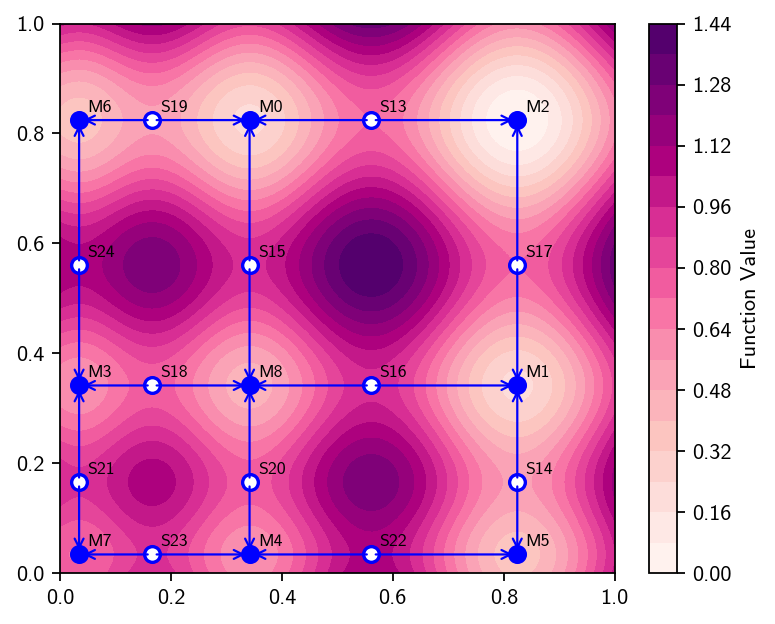

In [6]:
# visualise connectivity graph and landscape contours
from schwefel_function_jax import _schwefel
schwefel2D_numpy = _schwefel

fig2 = plt.figure(figsize=(5,4), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_df=dataframe,
                                connectivity_df=connectivity_df, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
fig2.show()
fig2.savefig(outdir+"/landscape_paths.png")  # Optional

/tmp/ipykernel_2778112/3697319739.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


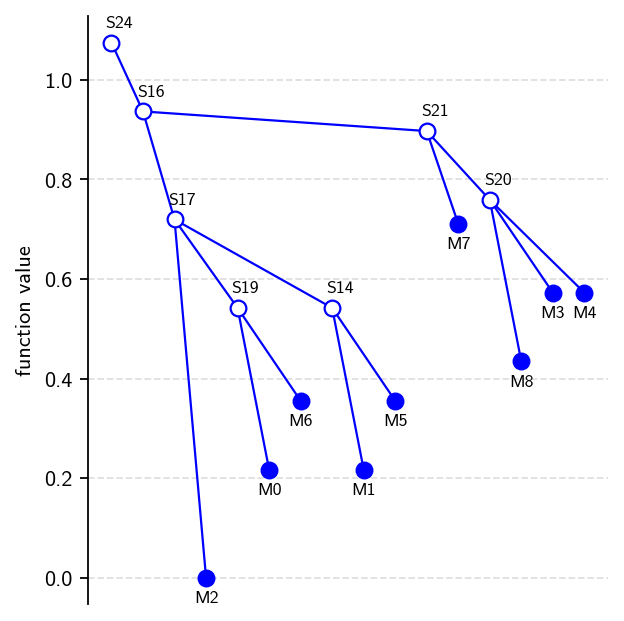

In [7]:
# visualise merge tree

fig1 = plt.figure(figsize=(4,4), dpi=160)
fig1 = plot_saddle_tree_with_function(dataframe, 
                                      nodes_csv=outdir+"/tree_nodes.csv",
                                      edges_csv=outdir+"/tree_connectivity.csv", 
                                      fig=fig1,
                                      txt_pads=(5e-1, 4e-2))

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig(outdir+"/tree_plot.png")  # Optional